# 03 — Chart Types
**Goal:** Know which chart to use for which question, and how to build each one correctly.

| Chart | Best for |
|---|---|
| Line | Trends over time |
| Bar | Comparing categories |
| Horizontal bar | Many categories or long labels |
| Histogram | Distribution of one metric |
| Boxplot | Distribution + outliers across groups |
| Scatter | Correlation between two metrics |
| Area | Cumulative or stacked trends |

In [2]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Global style — clean and consistent across all charts in this notebook
plt.rcParams.update({
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.color':        '#e8e8e8',
    'grid.linewidth':    0.8,
    'axes.axisbelow':    True,   # correct key: axes.axisbelow (not axes.set_axisbelow)
    'font.size':         11,
})

# Fintech funnel data
np.random.seed(42)
df = pd.read_csv('data/raw/funnel_data.csv', parse_dates=['date'])
print(df.shape, df.columns.tolist())

(450, 12) ['date', 'channel', 'visita_landing', 'inicio_solicitud', 'datos_personales', 'otp', 'datos_financieros', 'carga_documentos', 'evaluacion_crediticia', 'aprobacion', 'firma_digital', 'activacion_tarjeta']


## 1. Line chart — trend over time

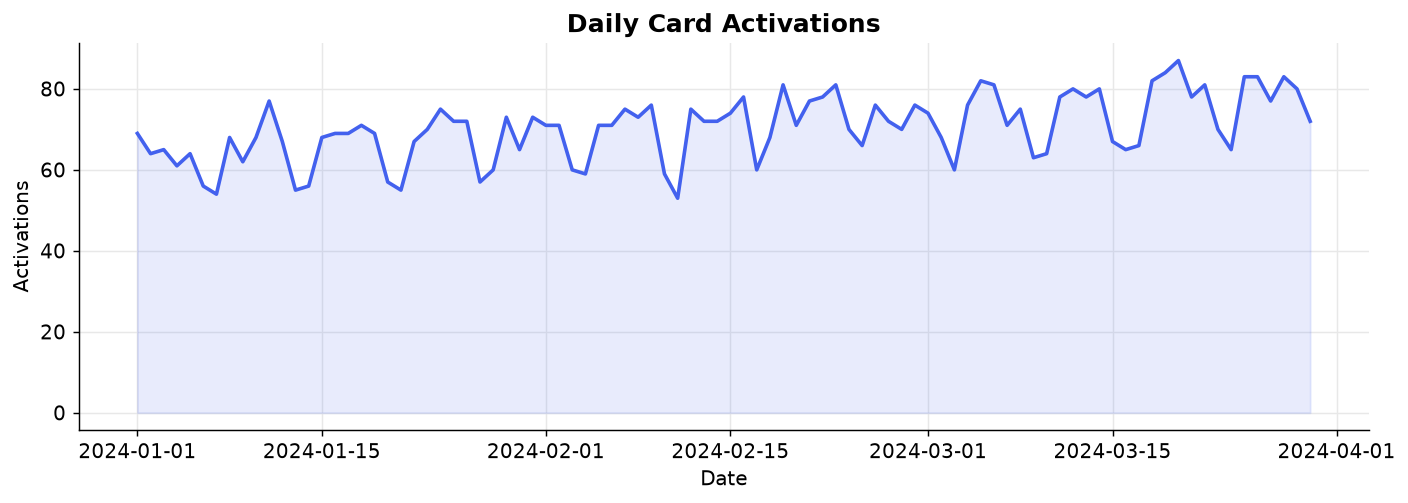

In [3]:
# Aggregate daily activations across all channels
daily = df.groupby('date')['activacion_tarjeta'].sum().reset_index()

fig, ax = plt.subplots(figsize=(11, 4), dpi=130)

ax.plot(daily['date'], daily['activacion_tarjeta'],
        color='#4361ee', linewidth=2)

# Fill below the line — emphasizes volume, not just trend
ax.fill_between(daily['date'], daily['activacion_tarjeta'],
                alpha=0.12, color='#4361ee')

ax.set_title('Daily Card Activations', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Activations')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 2. Bar chart — comparing categories

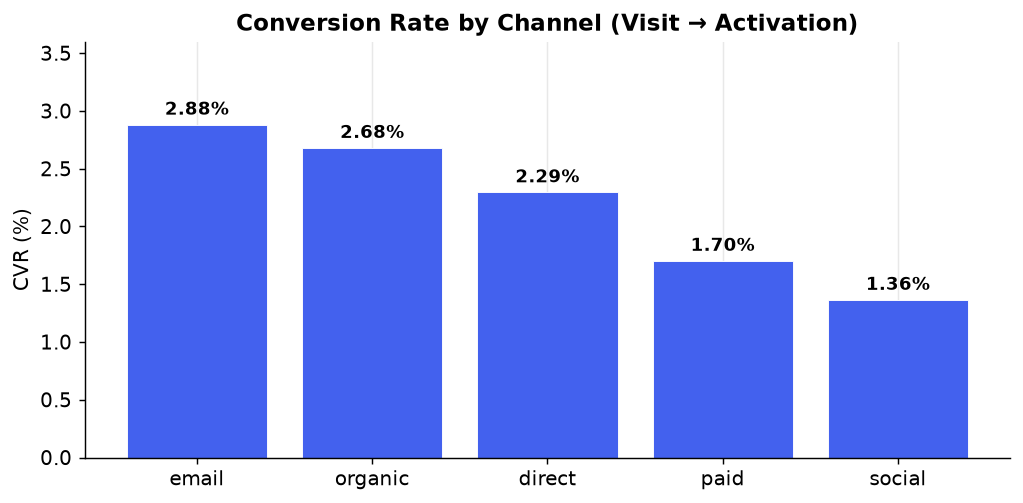

In [4]:
# CVR per channel: activations / visits
channel_stats = df.groupby('channel').agg(
    visits=('visita_landing', 'sum'),
    activations=('activacion_tarjeta', 'sum')
).reset_index()
channel_stats['cvr'] = channel_stats['activations'] / channel_stats['visits'] * 100
channel_stats = channel_stats.sort_values('cvr', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4), dpi=130)

bars = ax.bar(channel_stats['channel'], channel_stats['cvr'],
              color='#4361ee', edgecolor='white', linewidth=0.5)

# Add value labels on top of each bar
for bar, val in zip(bars, channel_stats['cvr']):
    ax.text(bar.get_x() + bar.get_width() / 2,   # x: center of bar
            bar.get_height() + 0.05,              # y: just above the bar
            f'{val:.2f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Conversion Rate by Channel (Visit → Activation)', fontsize=13, fontweight='bold')
ax.set_ylabel('CVR (%)')
ax.set_ylim(0, channel_stats['cvr'].max() * 1.25)  # extra space for labels
ax.grid(axis='y')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 3. Horizontal bar — many categories or long labels

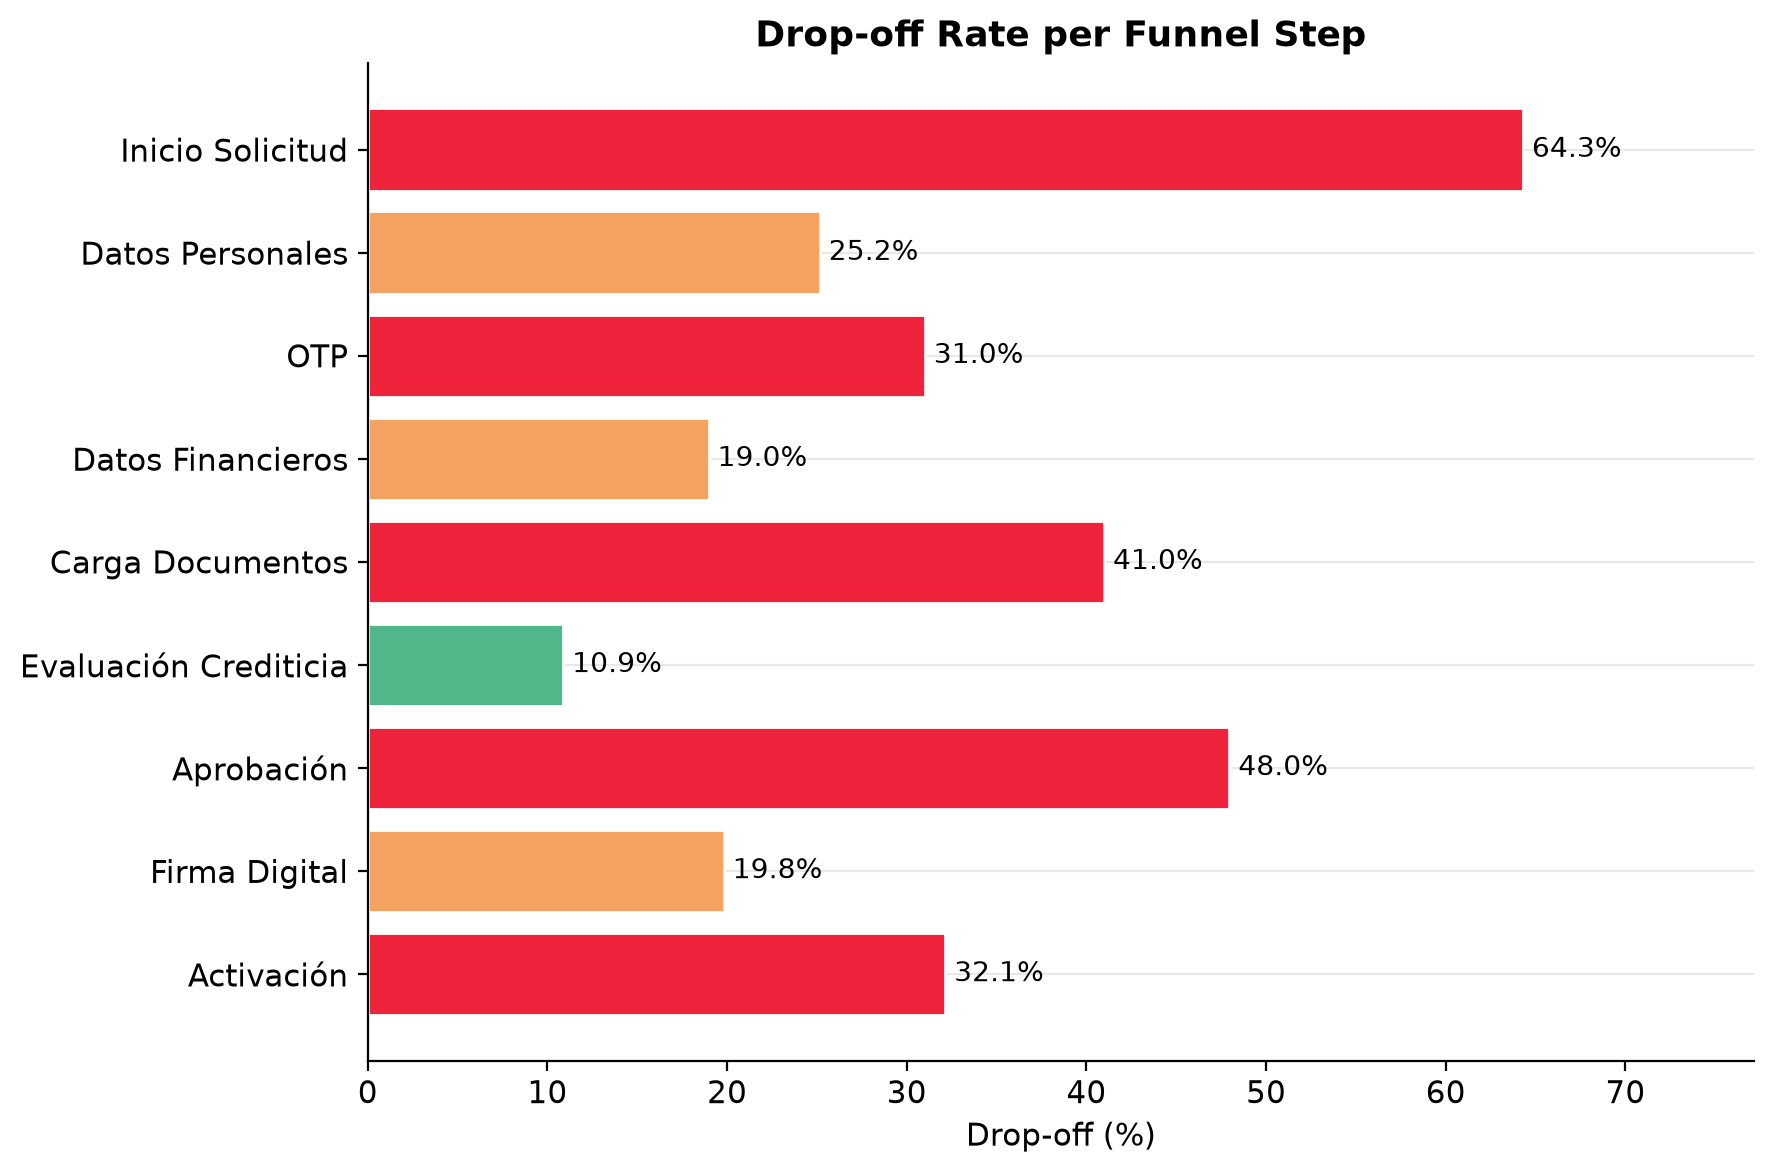

In [5]:
# Drop-off rate at each funnel step
steps = ['inicio_solicitud','datos_personales','otp','datos_financieros',
         'carga_documentos','evaluacion_crediticia','aprobacion','firma_digital','activacion_tarjeta']
step_labels = ['Inicio Solicitud','Datos Personales','OTP','Datos Financieros',
               'Carga Documentos','Evaluación Crediticia','Aprobación','Firma Digital','Activación']
prev_step = ['visita_landing','inicio_solicitud','datos_personales','otp','datos_financieros',
             'carga_documentos','evaluacion_crediticia','aprobacion','firma_digital']

totals = df[steps + ['visita_landing']].sum()
drops = [(totals[prev_step[i]] - totals[steps[i]]) / totals[prev_step[i]] * 100
         for i in range(len(steps))]

# Color by severity: red > 30%, orange > 15%, green otherwise
colors = ['#ef233c' if d > 30 else '#f4a261' if d > 15 else '#52b788' for d in drops]

fig, ax = plt.subplots(figsize=(9, 6), dpi=200)

# barh = horizontal bar
bars = ax.barh(step_labels, drops, color=colors, edgecolor='white')

# Labels at the end of each bar
for bar, val in zip(bars, drops):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=10)

ax.set_title('Drop-off Rate per Funnel Step', fontsize=13, fontweight='bold')
ax.set_xlabel('Drop-off (%)')
ax.set_xlim(0, max(drops) * 1.2)
ax.grid(axis='x')
ax.invert_yaxis()  # show first step at the top

plt.tight_layout()
plt.show()

## 4. Histogram — distribution of a metric

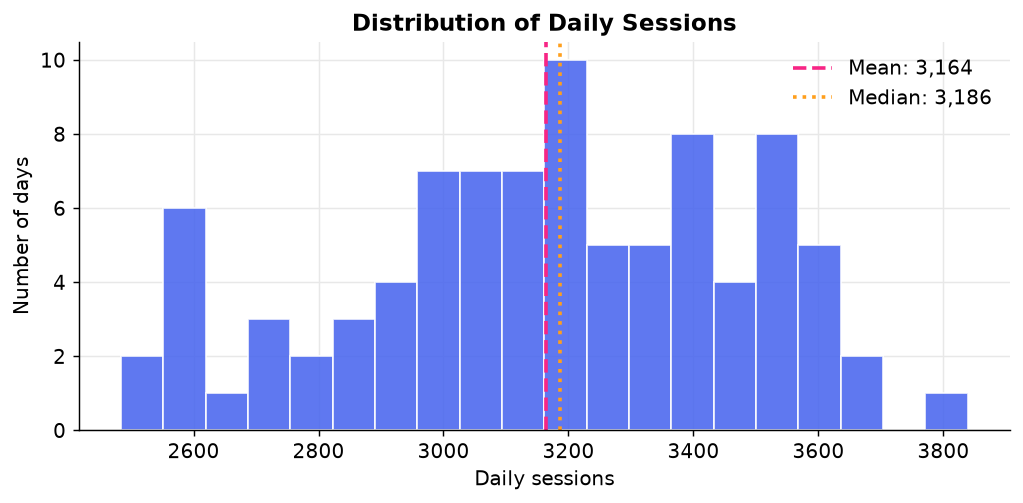

In [6]:
# Daily sessions distribution — are most days low or high traffic?
daily_sessions = df.groupby('date')['visita_landing'].sum()

fig, ax = plt.subplots(figsize=(8, 4), dpi=130)

# bins = number of buckets to split the data into
# edgecolor separates the bars visually
ax.hist(daily_sessions, bins=20, color='#4361ee', edgecolor='white', alpha=0.85)

# Reference lines for mean and median
ax.axvline(daily_sessions.mean(),   color='#f72585', linewidth=2,
           linestyle='--', label=f'Mean: {daily_sessions.mean():,.0f}')
ax.axvline(daily_sessions.median(), color='#ff9f1c', linewidth=2,
           linestyle=':', label=f'Median: {daily_sessions.median():,.0f}')

ax.set_title('Distribution of Daily Sessions', fontsize=13, fontweight='bold')
ax.set_xlabel('Daily sessions')
ax.set_ylabel('Number of days')
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

## 5. Boxplot — distribution + outliers across groups

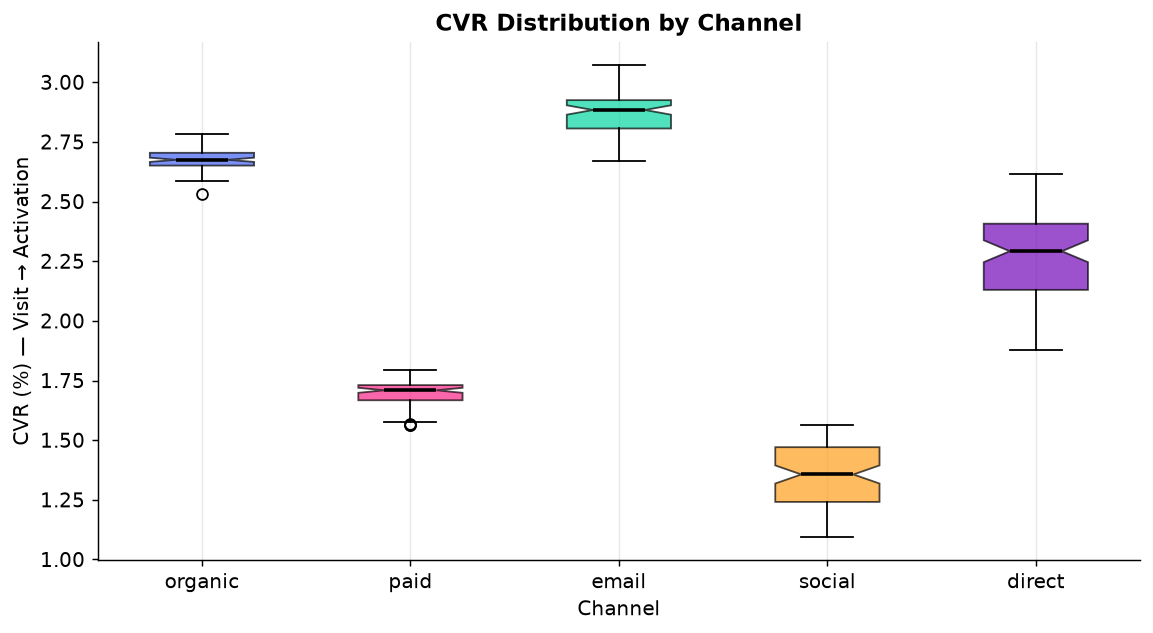

In [7]:
# CVR distribution per channel — shows median, spread, and outliers
channels = df['channel'].unique()
cvr_by_channel = [
    (df[df['channel'] == ch]['activacion_tarjeta'] /
     df[df['channel'] == ch]['visita_landing'] * 100).values
    for ch in channels
]

fig, ax = plt.subplots(figsize=(9, 5), dpi=130)

bp = ax.boxplot(cvr_by_channel,
                tick_labels=channels,
                patch_artist=True,     # fill boxes with color
                notch=True,            # notch shows confidence interval around median
                medianprops=dict(color='black', linewidth=2))

palette = ['#4361ee', '#f72585', '#06d6a0', '#ff9f1c', '#7209b7']
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('CVR Distribution by Channel', fontsize=13, fontweight='bold')
ax.set_ylabel('CVR (%) — Visit → Activation')
ax.set_xlabel('Channel')
ax.grid(axis='y')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Reading a boxplot:
# - Line inside box = median
# - Box edges = 25th and 75th percentile (IQR)
# - Whiskers = data within 1.5x IQR
# - Dots beyond whiskers = outliers

## 6. Scatter plot — correlation between two metrics

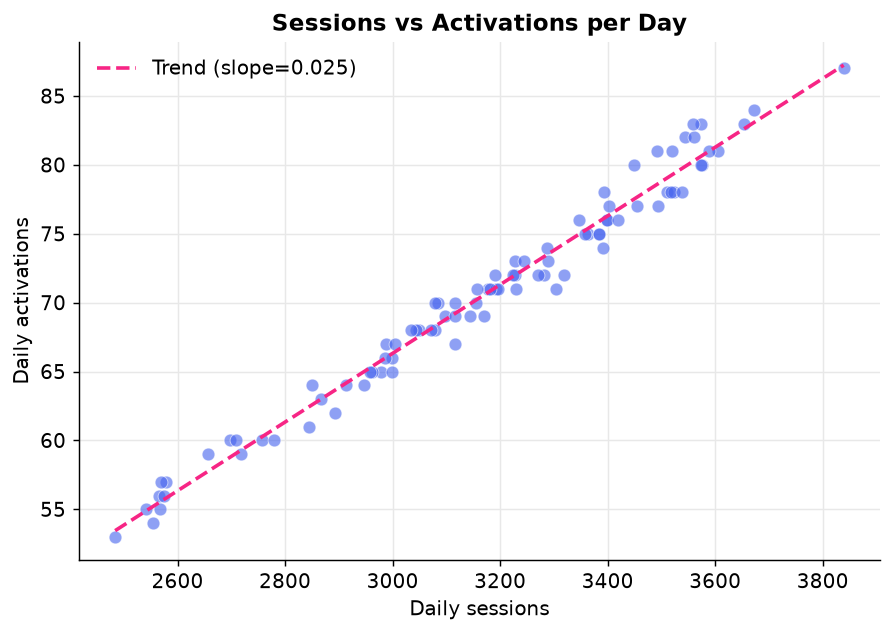

In [8]:
# Does more traffic mean more activations? Scatter shows the relationship
daily_agg = df.groupby('date').agg(
    sessions=('visita_landing', 'sum'),
    activations=('activacion_tarjeta', 'sum')
).reset_index()

fig, ax = plt.subplots(figsize=(7, 5), dpi=130)

# s = dot size, alpha = transparency (useful when dots overlap)
ax.scatter(daily_agg['sessions'], daily_agg['activations'],
           color='#4361ee', alpha=0.6, s=50, edgecolors='white', linewidth=0.5)

# Add a trend line (linear regression)
m, b = np.polyfit(daily_agg['sessions'], daily_agg['activations'], deg=1)
x_line = np.linspace(daily_agg['sessions'].min(), daily_agg['sessions'].max(), 100)
ax.plot(x_line, m * x_line + b, color='#f72585', linewidth=2,
        linestyle='--', label=f'Trend (slope={m:.3f})')

ax.set_title('Sessions vs Activations per Day', fontsize=13, fontweight='bold')
ax.set_xlabel('Daily sessions')
ax.set_ylabel('Daily activations')
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

## 7. Stacked area — composition over time

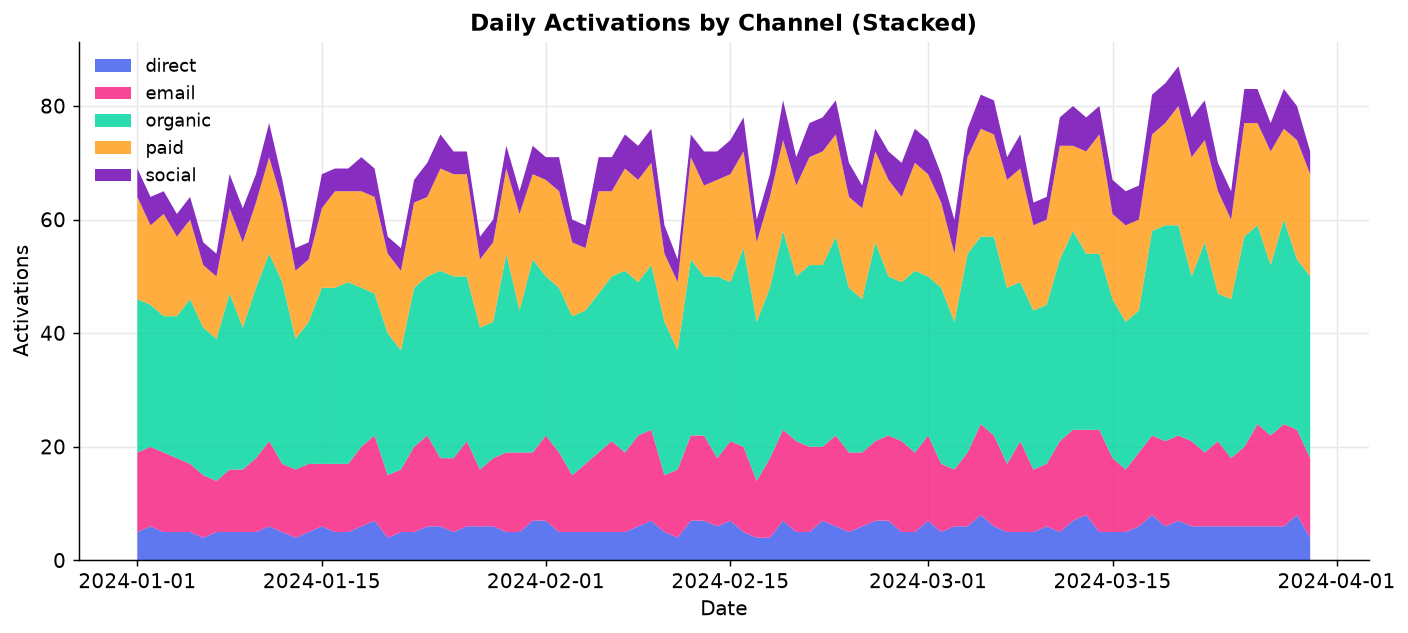

In [9]:
# Activations per channel stacked — shows volume AND composition
pivot = df.pivot_table(index='date', columns='channel',
                        values='activacion_tarjeta', aggfunc='sum').fillna(0)

fig, ax = plt.subplots(figsize=(11, 5), dpi=130)

palette = ['#4361ee', '#f72585', '#06d6a0', '#ff9f1c', '#7209b7']

# stackplot stacks each series on top of the previous one
ax.stackplot(pivot.index, pivot.T.values,
             labels=pivot.columns,
             colors=palette, alpha=0.85)

ax.set_title('Daily Activations by Channel (Stacked)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Activations')

# Legend outside so it doesn't cover the data
ax.legend(loc='upper left', frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

## Summary — when to use each chart

| Question | Chart |
|---|---|
| How did X change over time? | Line |
| Which channel performs best? | Bar |
| Where does the funnel drop? | Horizontal bar |
| What does the distribution look like? | Histogram |
| How does spread compare across groups? | Boxplot |
| Is there correlation between X and Y? | Scatter |
| What is the composition over time? | Stacked area |

**Next:** `04_subplots_layouts.ipynb` — combining multiple charts in one figure.